# On extracting matrix elements and a bit on quaternions
The objective is to extract all ingredients from DIRAC to form the one electron Fock operator. Here we will show how we got there. 

In DIRAC, almost everything is stored in quaternion form, due to the reduction of a factor of two of memory and computations, as it is possible to solve the generalized eigenproblem on quaternions, similar to regular matrices: 

$$
 ^{Q}F \ ^{Q}c = \varepsilon \ ^{Q}S \ ^{Q} c
$$

So we have to deal with that. Matrix elements are packed in triangular form, and also in quaternion form in certain cases. Up to this point, only Molfield, Betamat, and Overlap were availiable. After a minor change, where the kinetic energy and the one electron fock matrix rest were dumped too, we obtain the following objects: 

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

from typing import Optional, Union

from py_mods.src.SCF.plot_utilities import plot_map

In [2]:
availiable_in_h5 = []


def _show(name, obj):
    if isinstance(obj, h5py.Group):
        availiable_in_h5.append(f"Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        availiable_in_h5.append(f"Dataset: {name} {obj.shape}")


with h5py.File(f"files/He_checkpoint.h5", "r") as f:
    f.visititems(_show)

availiable_in_h5

['Group: input',
 'Group: input/aobasis',
 'Group: input/aobasis/1',
 'Dataset: input/aobasis/1/angular (1,)',
 'Dataset: input/aobasis/1/aobasis_id (1,)',
 'Dataset: input/aobasis/1/center (21,)',
 'Dataset: input/aobasis/1/contractions (7,)',
 'Dataset: input/aobasis/1/exponents (7,)',
 'Dataset: input/aobasis/1/n_ao (1,)',
 'Dataset: input/aobasis/1/n_cont (7,)',
 'Dataset: input/aobasis/1/n_prim (7,)',
 'Dataset: input/aobasis/1/n_shells (1,)',
 'Dataset: input/aobasis/1/orbmom (7,)',
 'Group: input/aobasis/2',
 'Dataset: input/aobasis/2/angular (1,)',
 'Dataset: input/aobasis/2/aobasis_id (1,)',
 'Dataset: input/aobasis/2/center (24,)',
 'Dataset: input/aobasis/2/contractions (8,)',
 'Dataset: input/aobasis/2/exponents (8,)',
 'Dataset: input/aobasis/2/n_ao (1,)',
 'Dataset: input/aobasis/2/n_cont (8,)',
 'Dataset: input/aobasis/2/n_prim (8,)',
 'Dataset: input/aobasis/2/n_shells (1,)',
 'Dataset: input/aobasis/2/orbmom (8,)',
 'Dataset: input/dirac_inp (27,)',
 'Group: input/mole

Where we can see the dimensions. In this particular hydrogen case, we have $34$ ($\{\phi^{L}\} \cup \{\phi^{S}\}$) basis functions. The total size of the **spin-independent** block will be a $34 \times 34$ matrix. If it is (anti)symmetric, we can pack that up using a single triangle:

$$
S^{triang}_{\mu \nu} = \begin{pmatrix}
d_{11} & \mathbf{0} & \mathbf{ 0} \\
  & \ddots  & \mathbf{ 0 } \\
\mathbf{A}_{mn} & & d_{nn}
\end{pmatrix}
$$
where $A$ is a non-zero matrix. The total number of non-zero elements of the matrix will be:

$$
n_{S_{\mu \nu}^{Triang}} = \frac{N \cdot (N+1)}{2}
$$
In the case we are showing:

$$
\frac{34 \cdot 35}{2} = 595
$$
Which fits. Also from this, it follows that:

$$ 
N^2 + N = 2 \cdot \mathrm{len(overlap)} \implies N = \frac{-1 + (\pm) \sqrt{1-4\cdot2\cdot\mathrm{len(overlap)}}}{2}
$$

Where the strictly positive solution is chosen due to the need of $N$ to exist. 

Therefore, now the question is how to unpack this flat array. Assuming column-major storage (due to Fortran), and row-major $2D$ arrays (due to NumPy being C) the unpack loop would be: 

In [3]:
def retriangularize(array, n_basis, antisymmetric=False):
    M = np.zeros((n_basis, n_basis), dtype=array.dtype)
    k = 0

    for j in range(n_basis):
        for i in range(j + 1):
            M[i, j] = array[k]
            M[j, i] = array[k] if not antisymmetric else -array[k]
            k += 1
    return M

And a plotting utility:

In [4]:
def plot_packed_heatmap(
    array,
    n,
    antisymmetric=False,
    LC_size: Optional[Union[int, None]] = None,
    title="Packed matrix heatmap",
    cmap="viridis",
    only_LC: bool = False,
):
    M = retriangularize(array, n, antisymmetric)
    Mplot = M.real if np.iscomplexobj(M) else M

    fig, ax = plt.subplots(figsize=(8, 7))
    if only_LC:
        ax.set_xlim(0, LC_size)
        ax.set_ylim(0, LC_size)

    im = ax.imshow(Mplot, cmap=cmap, origin="upper", aspect="auto")
    fig.colorbar(im, ax=ax, label="Matrix element")

    ax.set_xlabel("AO index")
    ax.set_ylabel("AO index")
    ax.set_title(title)

    if LC_size is not None:
        ax.axvline(x=LC_size - 0.5, color="black", linewidth=1.5)
        ax.axhline(y=LC_size - 0.5, color="black", linewidth=1.5)

    plt.tight_layout()
    plt.show()

    return M


Therefore, we can get the flat arrays:

In [5]:
with h5py.File(f"files/He_checkpoint.h5", "r") as f:
    kinarray = np.asarray(f["result/operators/ao_matrices/RELKINEN"][()])
    molfield = np.asarray(f["result/operators/ao_matrices/MOLFIELDTFFT"][()])
    fockarra = np.asarray(f["result/operators/ao_matrices/ONEFOCK"][()])
    betamatarr = np.asarray(f["result/operators/ao_matrices/BETAMAT FFFT"][()])
    overlap = np.asarray(f["result/operators/ao_matrices/OVERLAP TFFT"][()])

First we reconstruct the symmetric ones overlap, V, and beta to obtain the matrix elements of $S$, $V$, and $W$:

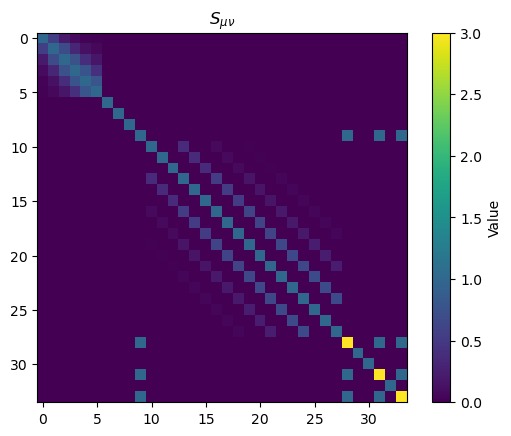

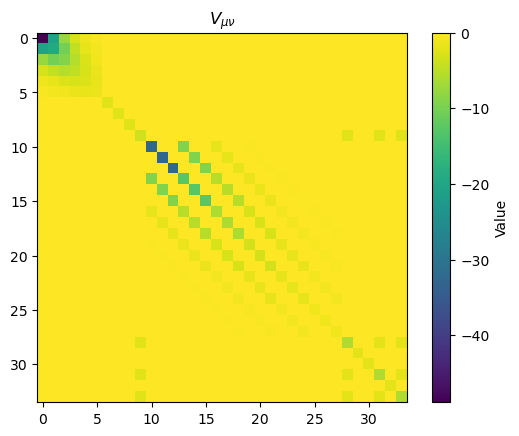

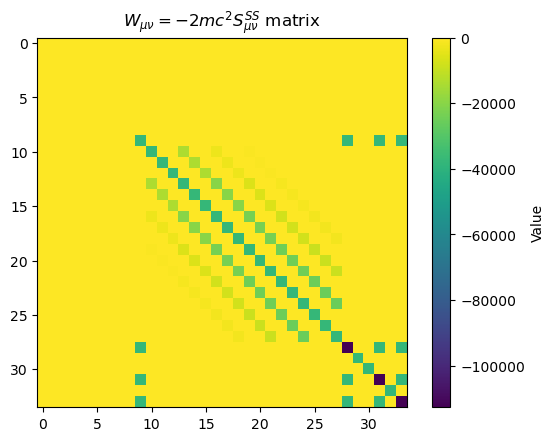

In [6]:
S = retriangularize(overlap, 34)
V = retriangularize(molfield, 34)
W = -retriangularize(betamatarr, 34) * 137.035999177**2 * 2 
plot_map(S, title="$S_{\\mu \\nu} $")
plot_map(V, title="$V_{\\mu \\nu} $")
plot_map(W, title="$W_{\\mu \\nu} = -2mc^{2}S^{SS}_{\\mu \\nu}$ matrix")


(where the value of $c$ was reverse eniginieered)

---

## Quaternion-stored data
The relativistic kinetic energy is stored not only triangular packed, but quaternion packed too. Therefore, we need to perform the relevant transformation to obtain the regular complex matrix representation of these quaternions. 

First, how do we know that it is quaternion packed? There is a nice indicator, and it is that the dimension ($1404$) is exactly four times the size of the spin independent arrays, indicating that the slices of $351$ elements will correspond to the triangular packed matrices of coefficients $c_0$, $c_{1}$, $c_{2},$ and $c_{3}$. 

Therefore, we can slice it, and unpack it: 

In [7]:
c0 = retriangularize(kinarray[0:595], 34, True)
c1 = retriangularize(kinarray[595:595*2], 34, True)
c2 = retriangularize(kinarray[595*2:595*3], 34, True)
c3 = retriangularize(kinarray[595*3:], 34, True)

Where these are unpacked antisymmetrically due to the kinetic energy operator being off diagonal, presenting that property from matrix representation of quaternion numbers. Recall that the complex quaternion representation matrix satisfies the formula:
      $$Q = \begin{pmatrix}Z & W \\ -W^* & Z^*\end{pmatrix}$$

where $Z = c_0 + i c_1 $ and $W = c_2 + i c_3$. The resulting matrix Q will have dimensions (2N, 2N) where N is the dimension of the input matrices $c_0$, $c_1$, $c_2$, $c_3$.

Then we can just with some accounting fill the correct places using the matrix definition of quaternion numbers:

In [8]:
def quaternion_to_matrix(c0,c1,c2,c3):
    Z = np.zeros_like(c0, dtype=np.complex128)
    Z.real = c0 
    Z.imag = c1
    W = np.zeros_like(c0, dtype=np.complex128)
    W.real = c2 
    W.imag = c3
    block_size = len(c1[0])
    Q = np.zeros([2*block_size,2*block_size], dtype=np.complex128)
    Q[0:block_size, 0:block_size] = Z
    Q[block_size:,block_size:] = np.conj(Z)
    Q[0:block_size, block_size:] = W
    Q[block_size:, 0:block_size] = -np.conj(W)
    return Q

In [9]:
T = quaternion_to_matrix(c0,c1,c2,c3)
VW = np.zeros_like(T)
VW[0:34, 0:34] = VW[34:,34:] = V + W
H_core = VW+T

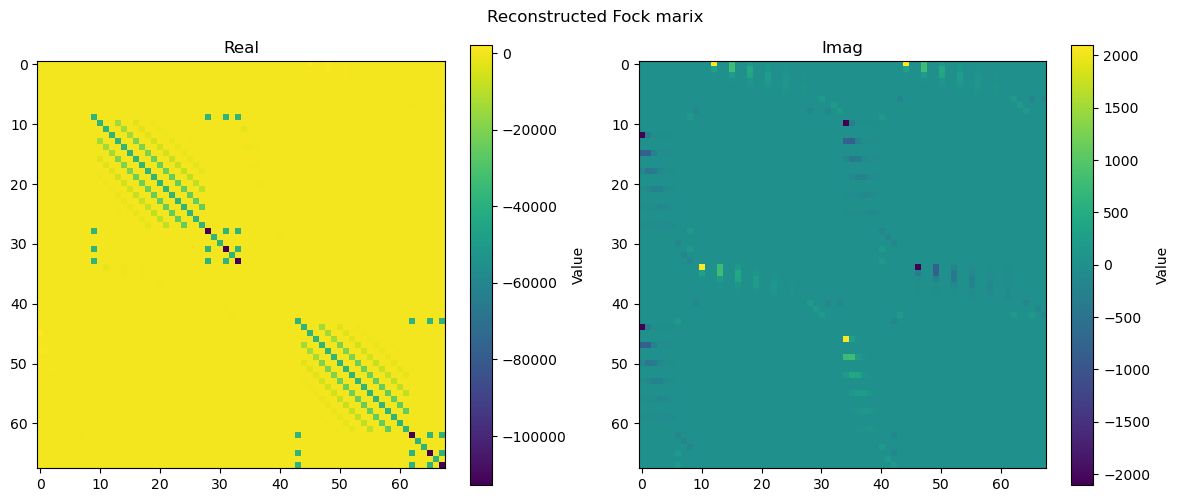

In [10]:
plot_map(H_core, title='Reconstructed Fock marix')

In the case of th **dumped** fock matrix, we can see that the size is $2704$, which can be factorized into: 

$$
4624 = 34 \cdot 34 \cdot 4
$$
Which indicates that the dumped Fock matrix is also dumped in packed in quaternion form, but **not** in triangular form. Therefore, we can reconstruct it as: 

In [11]:
focsquare = fockarra.reshape(4,34,34, order="C") # or manually, but this is convenient
f0, f1, f2, f3 = focsquare[0], focsquare[1], focsquare[2], focsquare[3]
Qf = quaternion_to_matrix(f0,f1,f2,f3)

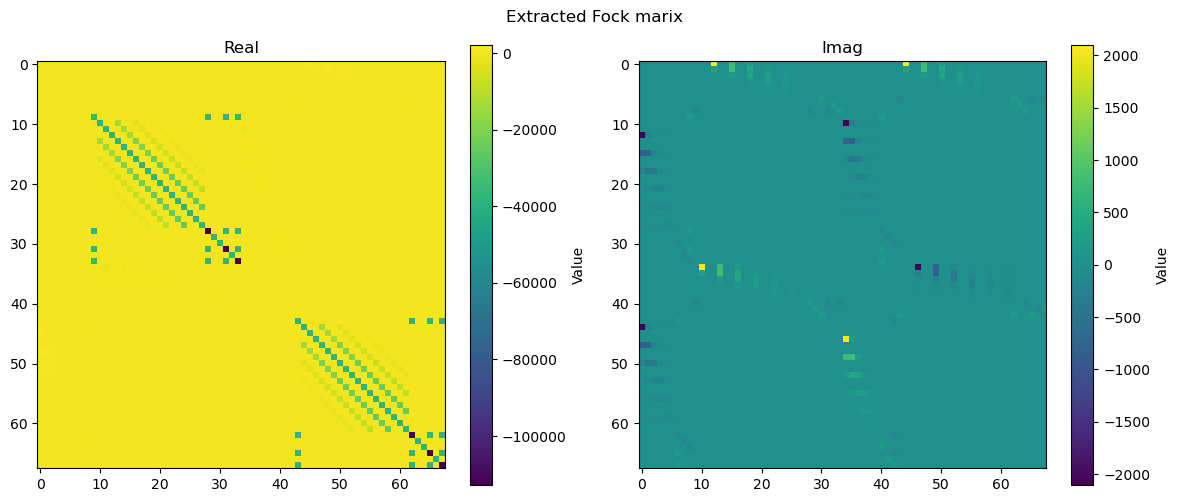

In [12]:
plot_map(Qf, title='Extracted Fock marix')

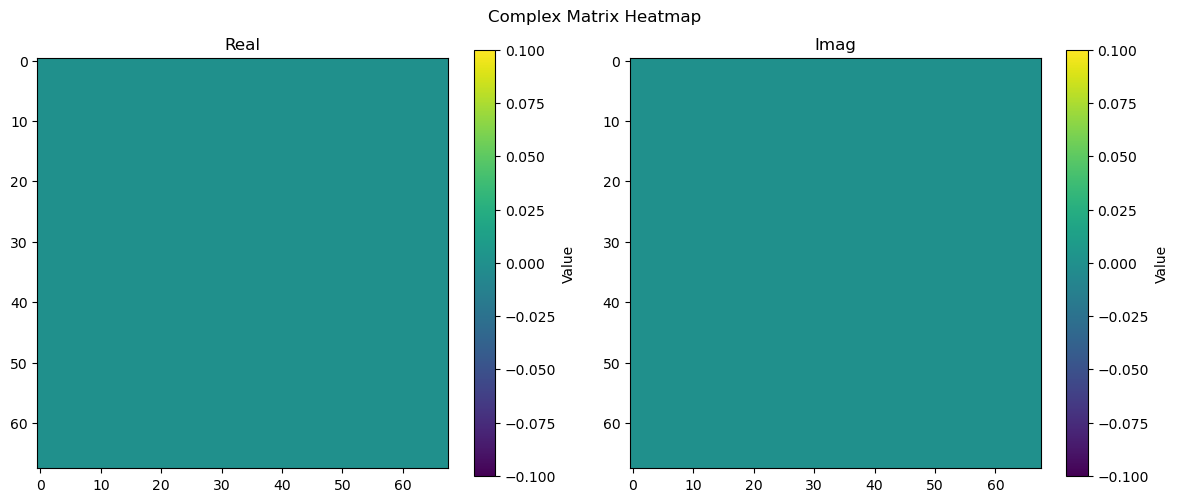

In [13]:
plot_map(Qf-H_core)

In [14]:
print(f'Max error in real part: {np.max(np.abs(Qf.real-H_core.real)) : .3e} ')
print(f'Max error in imag part: {np.max(np.abs(Qf.imag-H_core.imag)) : .3e} ')
print(f'Mean error in real part: {np.mean(np.abs(Qf.real-H_core.real)) : .3e} ')
print(f'Mean error in imag part: {np.mean(np.abs(Qf.imag-H_core.imag)) : .3e} ')

Max error in real part:  0.000e+00 
Max error in imag part:  0.000e+00 
Mean error in real part:  0.000e+00 
Mean error in imag part:  0.000e+00 
